<a href="https://colab.research.google.com/github/Lariiuki/ASGI/blob/main/Imagem_analise2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [187]:
import pandas as pd

In [188]:
df = pd.read_csv('/content/Analise2 - Cod_CCot_Cot - Custo.csv')

In [189]:
df.head()

,Modelo,duration_minimo,duration_maximo,duration_medio,duration_total,custo_minimo,custo_maximo,custo_media,custo_diff media,custo_total,porc_total
0,gpt-5/CoT,"19,18","59,68","44,01440","880,28","0,017556","0,038811","0,028681",0,"0,573625",0
1,gpt-5/CoD1,"20,26","58,67","40,37000","807,40","0,017151","0,034556","0,027429","-0,001252","0,54858","-4,37"
2,gpt-5/CoD2,"17,51","57,90","41,47800","829,56","0,015899","0,036249","0,027456","-0,001225","0,549115","-4,27"
3,gpt-5/CoD3,"17,47","57,73","41,18700","823,74","0,015875","0,037004","0,027417","-0,001264","0,548345","-4,41"
4,gpt-5/CCoT,"13,89","45,74","27,08350","541,67","0,017621","0,044015","0,028921","0,00024","0,578420","0,84"


In [190]:
colunas_float = ["duration_minimo", "duration_maximo", "duration_medio",
                 "custo_minimo", "custo_maximo", "custo_media"]

for col in colunas_float:
    df[col] = df[col].str.replace(",", ".").astype(float)

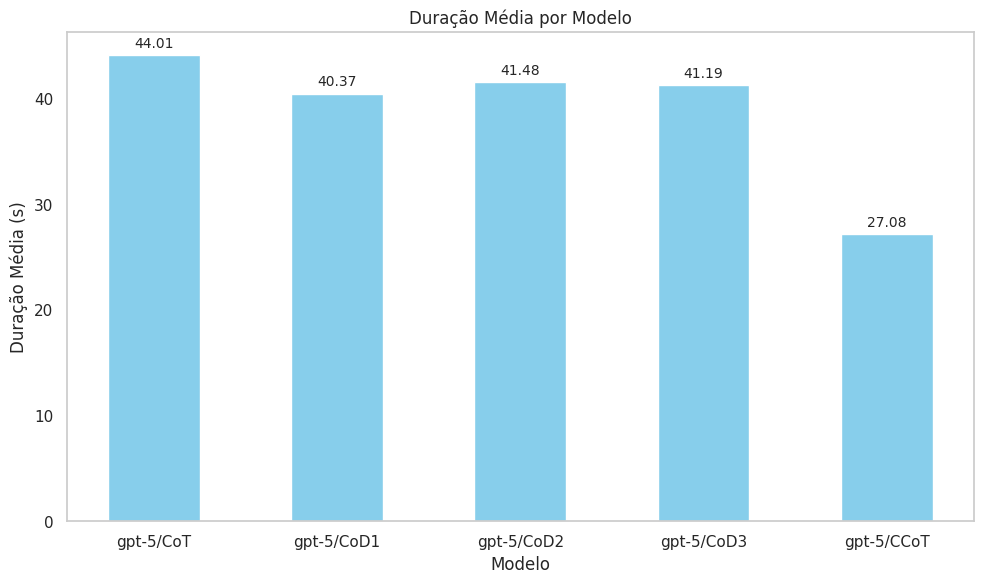

In [191]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Gráfico de barras
bars = plt.bar(df["Modelo"], df["duration_medio"], color='skyblue', width=0.5)

# Adicionar valores no topo de cada barra
for bar, valor in zip(bars, df["duration_medio"]):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, f"{valor:.2f}",
             ha='center', va='bottom', fontsize=10)

# Labels e título
plt.ylabel('Duração Média (s)')
plt.xlabel('Modelo')
plt.title('Duração Média por Modelo')

# Visual limpo
plt.grid(False)
plt.tight_layout()
plt.show()

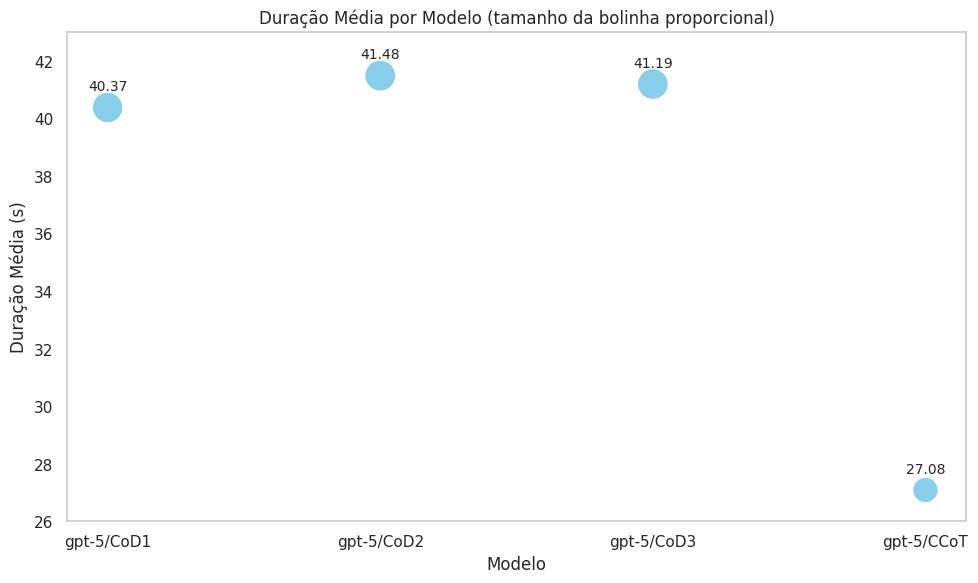

In [192]:
# Filtrar para remover o modelo CoT
df_filtered = df[df["Modelo"] != "gpt-5/CoT"].reset_index(drop=True)

x = np.arange(len(df_filtered))
values = df_filtered["duration_medio"]

plt.figure(figsize=(10,6))

# Tamanho das bolinhas proporcional à duração média
sizes = [val * 10 for val in values]  # ajuste o multiplicador se quiser bolinhas maiores/menores

# Scatter plot (bolinhas)
plt.scatter(x, values, color='skyblue', s=sizes)

# Adicionar valores acima das bolinhas
for xi, val in zip(x, values):
    plt.text(xi, val + 0.5, f"{val:.2f}", ha='center', va='bottom', fontsize=10)

# Rótulos do eixo X
plt.xticks(x, df_filtered["Modelo"], rotation=0, ha='center')

# Limites do eixo Y
plt.ylim(26, 43)

# Labels e título
plt.ylabel('Duração Média (s)')
plt.xlabel('Modelo')
plt.title('Duração Média por Modelo (tamanho da bolinha proporcional)')

# Visual limpo
plt.grid(False)
plt.tight_layout()
plt.show()

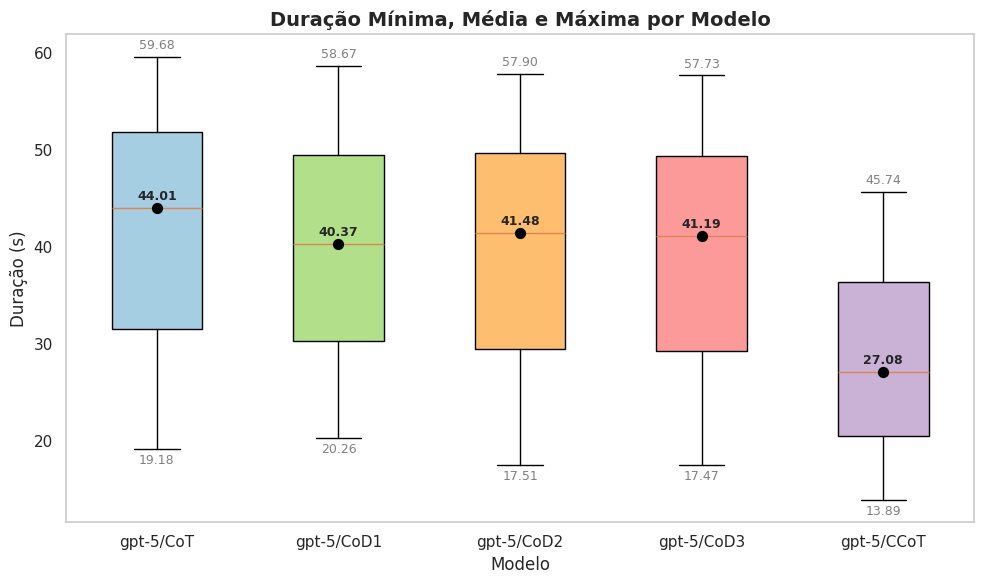

In [193]:
import matplotlib.pyplot as plt
import numpy as np

# Preparar dados: cada lista contém min, media, max (incluindo CoT)
data = []
for i, row in df.iterrows():
    data.append([row["duration_minimo"], row["duration_medio"], row["duration_maximo"]])

plt.figure(figsize=(10,6))

# Boxplot (customizado)
box = plt.boxplot(data, positions=np.arange(len(df)), widths=0.5, patch_artist=True,
                  showmeans=False, showfliers=False, whis=[0, 100])  # whis para min/max

# Cores suaves para cada box
colors = ['#A6CEE3', '#B2DF8A', '#FDBF6F', '#FB9A99', '#CAB2D6']  # adicionando uma cor para CoT
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

# Marcar a média como bolinha e adicionar valores
for i, row in enumerate(df.itertuples()):
    # Média
    plt.scatter(i, row.duration_medio, color='black', s=50, zorder=3)
    plt.text(i, row.duration_medio + 0.5, f"{row.duration_medio:.2f}", ha='center', va='bottom', fontsize=9, fontweight='bold')

    # Mínimo
    plt.text(i, row.duration_minimo - 0.5, f"{row.duration_minimo:.2f}", ha='center', va='top', fontsize=9, color='gray')

    # Máximo
    plt.text(i, row.duration_maximo + 0.5, f"{row.duration_maximo:.2f}", ha='center', va='bottom', fontsize=9, color='gray')

# Rótulos do eixo X
plt.xticks(np.arange(len(df)), df["Modelo"], rotation=0, ha='center')

# Labels e título
plt.ylabel('Duração (s)')
plt.xlabel('Modelo')
plt.title('Duração Mínima, Média e Máxima por Modelo', fontsize=14, fontweight='bold')

plt.grid(False)
plt.tight_layout()
plt.show()

In [194]:
df["custo_diff media"] = df["custo_diff media"].str.replace(',', '.').astype(float)

In [195]:
# Mostrar colunas importantes
display(df[["Modelo", "custo_media", "custo_diff media"]])

,Modelo,custo_media,custo_diff media
0,gpt-5/CoT,0.028681,0.000000
1,gpt-5/CoD1,0.027429,-0.001252
2,gpt-5/CoD2,0.027456,-0.001225
3,gpt-5/CoD3,0.027417,-0.001264
4,gpt-5/CCoT,0.028921,0.000240


,Modelo,custo_media,custo_diff media
0,gpt-5/CoD1,0.027429,-0.001252
1,gpt-5/CoD2,0.027456,-0.001225
2,gpt-5/CoD3,0.027417,-0.001264
3,gpt-5/CCoT,0.028921,0.000240


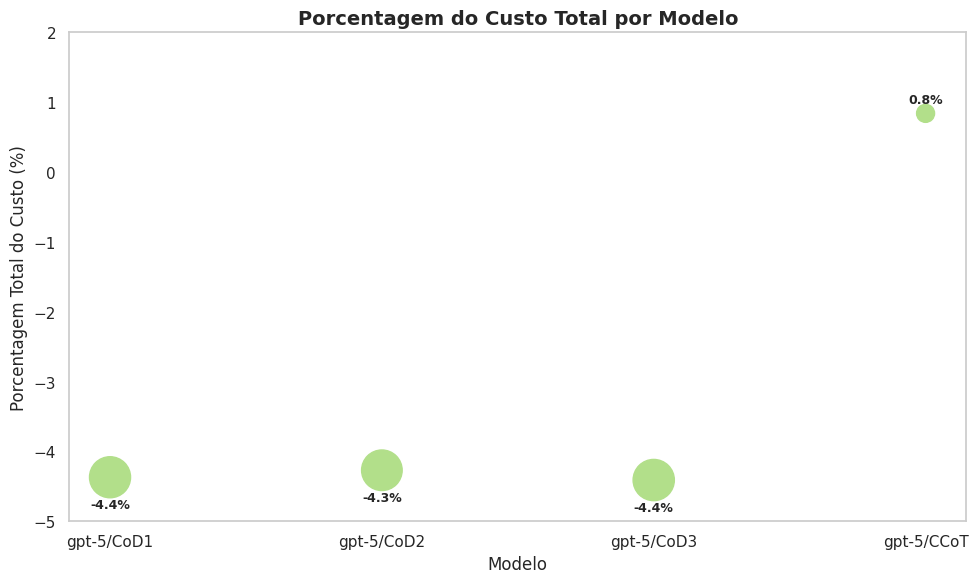

In [196]:
import matplotlib.pyplot as plt
import numpy as np

# Filtrar para remover o modelo CoT
df_filtered = df[df["Modelo"] != "gpt-5/CoT"].reset_index(drop=True)

# Agora exibir apenas as colunas desejadas
display(df_filtered[["Modelo", "custo_media", "custo_diff media"]])

# Garantir que a coluna seja float (substituindo vírgula por ponto, se houver)
df_filtered["porc_total"] = df_filtered["porc_total"].astype(str).str.replace(',', '.').astype(float)

x = np.arange(len(df_filtered))
values = df_filtered["porc_total"]

plt.figure(figsize=(10,6))

# Definir tamanho da bolinha proporcional ao valor absoluto
sizes = [abs(val)*200 for val in values]

# Scatter plot com tamanho variável
plt.scatter(x, values, color='#B2DF8A', s=sizes)

# Adicionar valores acima/abaixo das bolinhas
for xi, val in zip(x, values):
    offset = 0.1 if val >= 0 else -0.3  # ajustado para valores visíveis
    va = 'bottom' if val >= 0 else 'top'
    plt.text(xi, val + offset, f"{val:.1f}%", ha='center', va=va, fontsize=9, fontweight='bold')

# Rótulos do eixo X
plt.xticks(x, df_filtered["Modelo"], rotation=0, ha='center')

plt.ylim(-5, 2)

# Labels e título
plt.ylabel('Porcentagem Total do Custo (%)', fontsize=12)
plt.xlabel('Modelo', fontsize=12)
plt.title('Porcentagem do Custo Total por Modelo', fontsize=14, fontweight='bold')

plt.grid(False)
plt.tight_layout()
plt.show()

In [197]:
df_tokens = pd.read_csv('/content/Analise2 - Cod_CCot_Cot - Tokens.csv')

In [198]:
df_tokens.head()

,Modelo,min_prompt_tokens,max_prompt_tokens,mean_prompt_tokens,total_prompt_tokens,min_completions_tokens,max_completions_tokens,mean_completions_tokens,total_completions_tokens
0,gpt-5/CoT,6066,6093,6075.0,121500,994,3122,2108.75,42175
1,gpt-5/CoD1,5733,5760,5742.0,114840,998,2737,2025.15,40503
2,gpt-5/CoD2,5732,5759,5741.0,114820,870,2907,2027.95,40559
3,gpt-5/CoD3,5664,5691,5673.0,113460,879,2992,2032.60,40652
4,gpt-5/CCoT,6109,6136,6118.0,122360,998,3637,2127.35,42547


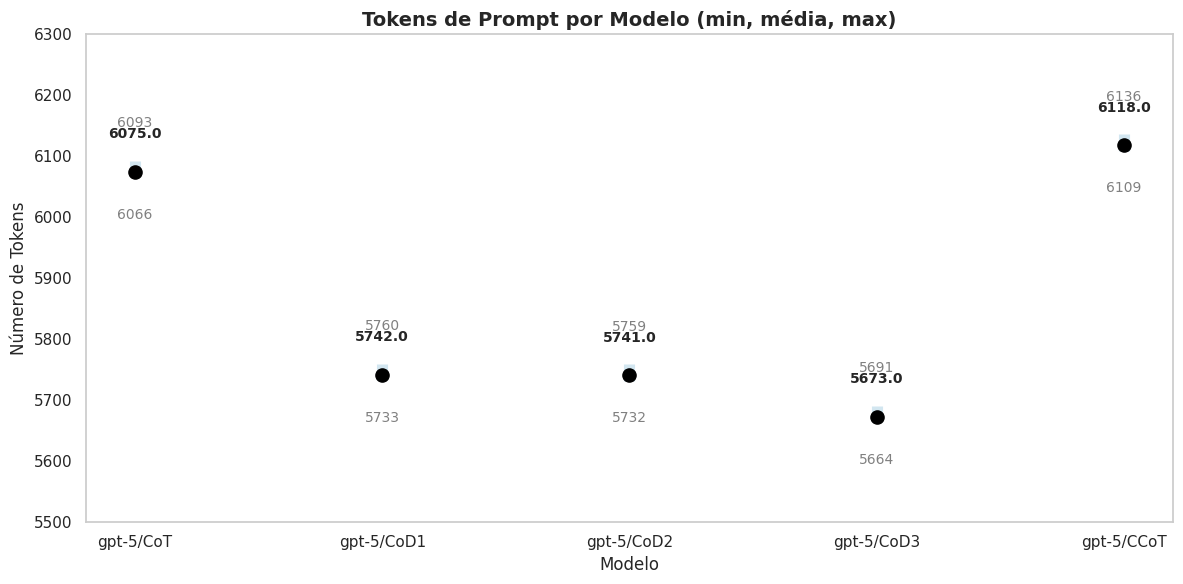

In [225]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(12,6))

x = np.arange(len(df_tokens))
for i, row in df_tokens.iterrows():
    # Linha do min ao max
    plt.vlines(x=i, ymin=row.min_prompt_tokens, ymax=row.max_prompt_tokens, color='#A6CEE3', linewidth=8, alpha=0.5)

    # Média
    plt.scatter(i, row.mean_prompt_tokens, color='black', s=90, zorder=2)

    # Adicionar valores
    plt.text(i, row.min_prompt_tokens - 50, f"{row.min_prompt_tokens}", ha='center', va='top', fontsize=10, color='gray')
    plt.text(i, row.mean_prompt_tokens + 50, f"{row.mean_prompt_tokens}", ha='center', va='bottom', fontsize=10, fontweight='bold')
    plt.text(i, row.max_prompt_tokens + 50, f"{row.max_prompt_tokens}", ha='center', va='bottom', fontsize=10, color='gray')

# Rótulos do eixo X
plt.xticks(x, df_tokens["Modelo"], rotation=0, ha='center')

plt.ylim(5500, 6300)

plt.ylabel('Número de Tokens')
plt.xlabel('Modelo')
plt.title('Tokens de Prompt por Modelo (min, média, max)', fontsize=14, fontweight='bold')
plt.grid(False)
plt.tight_layout()
plt.show()

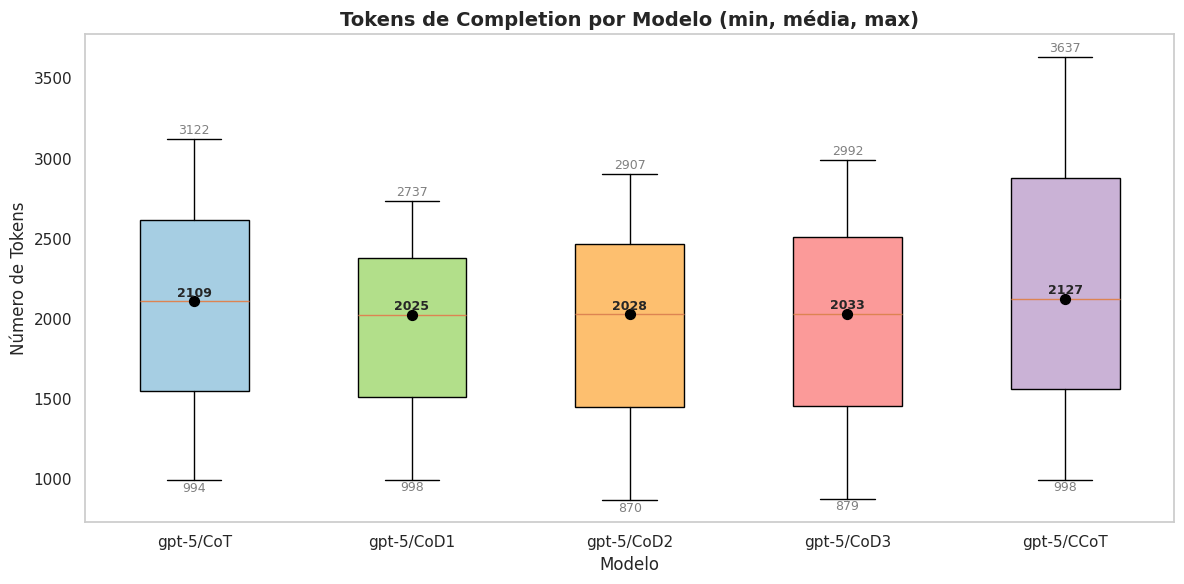

In [223]:
import matplotlib.pyplot as plt
import numpy as np

# Preparar dados do Completion
data_completion = []
for i, row in df_tokens.iterrows():
    data_completion.append([row["min_completions_tokens"], row["mean_completions_tokens"], row["max_completions_tokens"]])

plt.figure(figsize=(12,6))

# Boxplot customizado
box = plt.boxplot(data_completion, positions=np.arange(len(df_tokens)), widths=0.5, patch_artist=True,
                  showmeans=False, showfliers=False, whis=[0, 100])

# Cores suaves
colors = ['#A6CEE3', '#B2DF8A', '#FDBF6F', '#FB9A99', '#CAB2D6']
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)

# Adicionar média como bolinha e min/max como texto
for i, row in enumerate(df_tokens.itertuples()):
    # Média
    plt.scatter(i, row.mean_completions_tokens, color='black', s=50, zorder=3)
    plt.text(i, row.mean_completions_tokens + 10, f"{row.mean_completions_tokens:.0f}", ha='center', va='bottom', fontsize=9, fontweight='bold')

    # Mínimo
    plt.text(i, row.min_completions_tokens - 10, f"{row.min_completions_tokens:.0f}", ha='center', va='top', fontsize=9, color='gray')

    # Máximo
    plt.text(i, row.max_completions_tokens + 10, f"{row.max_completions_tokens:.0f}", ha='center', va='bottom', fontsize=9, color='gray')

# Rótulos do eixo X
plt.xticks(np.arange(len(df_tokens)), df_tokens["Modelo"], rotation=0, ha='center')

plt.ylabel('Número de Tokens')
plt.xlabel('Modelo')
plt.title('Tokens de Completion por Modelo (min, média, max)', fontsize=14, fontweight='bold')
plt.grid(False)
plt.tight_layout()
plt.show()